# Tutorial 14_A — Simple RNN for Named Entity Recognition (NER)

## Objective

This notebook implements **Tutorial 14_A: Building a Simple RNN for Named Entity Recognition (NER)** using PyTorch.

The tutorial covers:

- Preparing a small NER dataset
- Tokenizing sentences
- Converting words and labels into integers
- Padding sequences
- Building a Simple RNN model
- Training the model for word-level sequence labeling
- Testing the model on new sentences
- Creating our own dataset
- Changing number of hidden units, epochs, and learning rate

The task is:

> Make your own dataset and test it with the model. Also change the number of units, epochs, and learning rate.


## 1. Import Required Libraries

In [1]:
import os
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

os.makedirs("images", exist_ok=True)


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Prepare the NER Dataset

Named Entity Recognition is a sequence labeling task.

For each word in a sentence, the model predicts an entity label.

In this notebook, the labels are:

- `PERSON`
- `LOCATION`
- `ORGANIZATION`
- `O` for non-entity words

A padding label is also used internally for padded tokens.


In [2]:
# Own small NER dataset
# Each item contains tokenized sentence words and their matching NER labels.

dataset = [
    (
        ["Barack", "Obama", "was", "born", "in", "Hawaii"],
        ["PERSON", "PERSON", "O", "O", "O", "LOCATION"]
    ),
    (
        ["Google", "is", "based", "in", "Mountain", "View"],
        ["ORGANIZATION", "O", "O", "O", "LOCATION", "LOCATION"]
    ),
    (
        ["Microsoft", "was", "founded", "by", "Bill", "Gates"],
        ["ORGANIZATION", "O", "O", "O", "PERSON", "PERSON"]
    ),
    (
        ["Elon", "Musk", "works", "at", "Tesla"],
        ["PERSON", "PERSON", "O", "O", "ORGANIZATION"]
    ),
    (
        ["NUST", "is", "located", "in", "Islamabad"],
        ["ORGANIZATION", "O", "O", "O", "LOCATION"]
    ),
    (
        ["Ali", "Khan", "visited", "Lahore"],
        ["PERSON", "PERSON", "O", "LOCATION"]
    ),
    (
        ["Fatima", "studies", "at", "NUST"],
        ["PERSON", "O", "O", "ORGANIZATION"]
    ),
    (
        ["OpenAI", "has", "offices", "in", "San", "Francisco"],
        ["ORGANIZATION", "O", "O", "O", "LOCATION", "LOCATION"]
    ),
    (
        ["Apple", "was", "started", "by", "Steve", "Jobs"],
        ["ORGANIZATION", "O", "O", "O", "PERSON", "PERSON"]
    ),
    (
        ["Karachi", "is", "a", "large", "city", "in", "Pakistan"],
        ["LOCATION", "O", "O", "O", "O", "O", "LOCATION"]
    ),
    (
        ["Amazon", "was", "founded", "by", "Jeff", "Bezos"],
        ["ORGANIZATION", "O", "O", "O", "PERSON", "PERSON"]
    ),
    (
        ["Sara", "Ahmed", "moved", "to", "Rawalpindi"],
        ["PERSON", "PERSON", "O", "O", "LOCATION"]
    ),
    (
        ["Meta", "owns", "Facebook", "and", "Instagram"],
        ["ORGANIZATION", "O", "ORGANIZATION", "O", "ORGANIZATION"]
    ),
    (
        ["Paris", "is", "the", "capital", "of", "France"],
        ["LOCATION", "O", "O", "O", "O", "LOCATION"]
    ),
    (
        ["Mark", "Zuckerberg", "created", "Facebook"],
        ["PERSON", "PERSON", "O", "ORGANIZATION"]
    ),
    (
        ["Toyota", "is", "a", "company", "from", "Japan"],
        ["ORGANIZATION", "O", "O", "O", "O", "LOCATION"]
    ),
    (
        ["Ayesha", "works", "for", "Google", "in", "London"],
        ["PERSON", "O", "O", "ORGANIZATION", "O", "LOCATION"]
    ),
    (
        ["IBM", "opened", "a", "new", "office", "in", "Dubai"],
        ["ORGANIZATION", "O", "O", "O", "O", "O", "LOCATION"]
    ),
    (
        ["Cristiano", "Ronaldo", "played", "in", "Madrid"],
        ["PERSON", "PERSON", "O", "O", "LOCATION"]
    ),
    (
        ["Samsung", "is", "headquartered", "in", "Seoul"],
        ["ORGANIZATION", "O", "O", "O", "LOCATION"]
    ),
    (
        ["Hassan", "joined", "Microsoft", "after", "graduating", "from", "NUST"],
        ["PERSON", "O", "ORGANIZATION", "O", "O", "O", "ORGANIZATION"]
    ),
    (
        ["Twitter", "was", "bought", "by", "Elon", "Musk"],
        ["ORGANIZATION", "O", "O", "O", "PERSON", "PERSON"]
    ),
    (
        ["Maryam", "travelled", "from", "Islamabad", "to", "Karachi"],
        ["PERSON", "O", "O", "LOCATION", "O", "LOCATION"]
    ),
    (
        ["Netflix", "produces", "shows", "in", "America"],
        ["ORGANIZATION", "O", "O", "O", "LOCATION"]
    )
]

print("Number of sentences:", len(dataset))

for tokens, labels in dataset[:3]:
    print(tokens)
    print(labels)
    print()


Number of sentences: 24
['Barack', 'Obama', 'was', 'born', 'in', 'Hawaii']
['PERSON', 'PERSON', 'O', 'O', 'O', 'LOCATION']

['Google', 'is', 'based', 'in', 'Mountain', 'View']
['ORGANIZATION', 'O', 'O', 'O', 'LOCATION', 'LOCATION']

['Microsoft', 'was', 'founded', 'by', 'Bill', 'Gates']
['ORGANIZATION', 'O', 'O', 'O', 'PERSON', 'PERSON']



## 3. Build Vocabulary and Label Mappings

Each word is converted to an integer index.

Each NER label is also converted to an integer index.


In [3]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
PAD_LABEL = "<PAD>"

all_words = sorted(set(word.lower() for tokens, labels in dataset for word in tokens))
all_labels = sorted(set(label for tokens, labels in dataset for label in labels))

word_to_idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word in all_words:
    word_to_idx[word] = len(word_to_idx)

label_to_idx = {PAD_LABEL: 0}
for label in all_labels:
    label_to_idx[label] = len(label_to_idx)

idx_to_word = {idx: word for word, idx in word_to_idx.items()}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

print("Vocabulary size:", len(word_to_idx))
print("Labels:", label_to_idx)


Vocabulary size: 98
Labels: {'<PAD>': 0, 'LOCATION': 1, 'O': 2, 'ORGANIZATION': 3, 'PERSON': 4}


## 4. Encode and Pad Sequences

All sentences are padded to the same length.

The padding label is ignored during loss and accuracy calculation.


In [4]:
max_len = max(len(tokens) for tokens, labels in dataset)

def encode_sentence(tokens):
    encoded = [word_to_idx.get(word.lower(), word_to_idx[UNK_TOKEN]) for word in tokens]
    encoded += [word_to_idx[PAD_TOKEN]] * (max_len - len(encoded))
    return encoded

def encode_labels(labels):
    encoded = [label_to_idx[label] for label in labels]
    encoded += [label_to_idx[PAD_LABEL]] * (max_len - len(encoded))
    return encoded

X = np.array([encode_sentence(tokens) for tokens, labels in dataset], dtype=np.int64)
y = np.array([encode_labels(labels) for tokens, labels in dataset], dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Maximum sentence length:", max_len)

print("\nEncoded first sentence:")
print(X[0])
print(y[0])


X shape: (24, 7)
y shape: (24, 7)
Maximum sentence length: 7

Encoded first sentence:
[12 66 95 16 41 38  0]
[4 4 2 2 2 1 0]


## 5. Train/Test Split

In [5]:
indices = np.arange(len(dataset))
np.random.seed(SEED)
np.random.shuffle(indices)

split_index = int(0.8 * len(indices))

train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train = X[train_indices]
y_train = y[train_indices]

X_test = X[test_indices]
y_test = y[test_indices]

print("Training sentences:", len(X_train))
print("Testing sentences:", len(X_test))


Training sentences: 19
Testing sentences: 5


## 6. Create PyTorch Dataset and DataLoader

In [6]:
class NERDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = NERDataset(X_train, y_train)
test_dataset = NERDataset(X_test, y_test)

batch_size = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


## 7. Define the Simple RNN Model

The model structure is:

1. Embedding layer
2. Simple RNN layer
3. Dropout layer
4. Linear output layer

The model predicts a label for every token in the sentence.


In [7]:
class SimpleRNNNER(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_labels, dropout_rate=0.2):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=word_to_idx[PAD_TOKEN]
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_dim, num_labels)

    def forward(self, x):
        embedded = self.embedding(x)
        rnn_output, hidden = self.rnn(embedded)
        rnn_output = self.dropout(rnn_output)
        logits = self.classifier(rnn_output)
        return logits


baseline_model = SimpleRNNNER(
    vocab_size=len(word_to_idx),
    embedding_dim=64,
    hidden_dim=64,
    num_labels=len(label_to_idx),
    dropout_rate=0.2
).to(device)

print(baseline_model)


SimpleRNNNER(
  (embedding): Embedding(98, 64, padding_idx=0)
  (rnn): RNN(64, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=5, bias=True)
)


## 8. Training and Evaluation Functions

In [8]:
def token_accuracy(logits, labels):
    predictions = torch.argmax(logits, dim=-1)
    mask = labels != label_to_idx[PAD_LABEL]

    correct = ((predictions == labels) & mask).sum().item()
    total = mask.sum().item()

    if total == 0:
        return 0.0

    return correct / total


def train_rnn_ner(model, train_loader, test_loader, epochs=20, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss(ignore_index=label_to_idx[PAD_LABEL])
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_accuracy": [],
        "test_accuracy": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        model.train()

        train_loss = 0.0
        train_acc = 0.0
        train_batches = 0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_X)

            loss = criterion(
                logits.view(-1, logits.shape[-1]),
                batch_y.view(-1)
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += token_accuracy(logits, batch_y)
            train_batches += 1

        train_loss = train_loss / train_batches
        train_acc = train_acc / train_batches

        model.eval()

        test_loss = 0.0
        test_acc = 0.0
        test_batches = 0

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)

                logits = model(batch_X)

                loss = criterion(
                    logits.view(-1, logits.shape[-1]),
                    batch_y.view(-1)
                )

                test_loss += loss.item()
                test_acc += token_accuracy(logits, batch_y)
                test_batches += 1

        test_loss = test_loss / test_batches
        test_acc = test_acc / test_batches

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_accuracy"].append(train_acc)
        history["test_accuracy"].append(test_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Test Loss: {test_loss:.4f} | "
                f"Train Acc: {train_acc * 100:.2f}% | "
                f"Test Acc: {test_acc * 100:.2f}%"
            )

    total_time = time.time() - start_time

    return history, total_time


def plot_history(history, title, filename):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, history["test_accuracy"], label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 9. Train the Baseline RNN Model

In [9]:
torch.manual_seed(SEED)

baseline_model = SimpleRNNNER(
    vocab_size=len(word_to_idx),
    embedding_dim=64,
    hidden_dim=64,
    num_labels=len(label_to_idx),
    dropout_rate=0.2
).to(device)

baseline_history, baseline_time = train_rnn_ner(
    baseline_model,
    train_loader,
    test_loader,
    epochs=30,
    learning_rate=0.001
)

print("Baseline training time:", round(baseline_time, 2), "seconds")
print("Trainable parameters:", count_trainable_parameters(baseline_model))


Epoch 1/30 | Train Loss: 1.5624 | Test Loss: 1.4570 | Train Acc: 29.98% | Test Acc: 63.69%
Epoch 5/30 | Train Loss: 1.0628 | Test Loss: 1.1546 | Train Acc: 69.65% | Test Acc: 68.45%
Epoch 10/30 | Train Loss: 0.6526 | Test Loss: 0.8958 | Train Acc: 83.17% | Test Acc: 73.21%
Epoch 15/30 | Train Loss: 0.3925 | Test Loss: 0.7235 | Train Acc: 95.10% | Test Acc: 75.60%
Epoch 20/30 | Train Loss: 0.2448 | Test Loss: 0.6274 | Train Acc: 99.17% | Test Acc: 75.60%
Epoch 25/30 | Train Loss: 0.1472 | Test Loss: 0.5824 | Train Acc: 100.00% | Test Acc: 75.60%
Epoch 30/30 | Train Loss: 0.1080 | Test Loss: 0.5496 | Train Acc: 100.00% | Test Acc: 75.60%
Baseline training time: 1.0 seconds
Trainable parameters: 14917


## 10. Plot Baseline Results

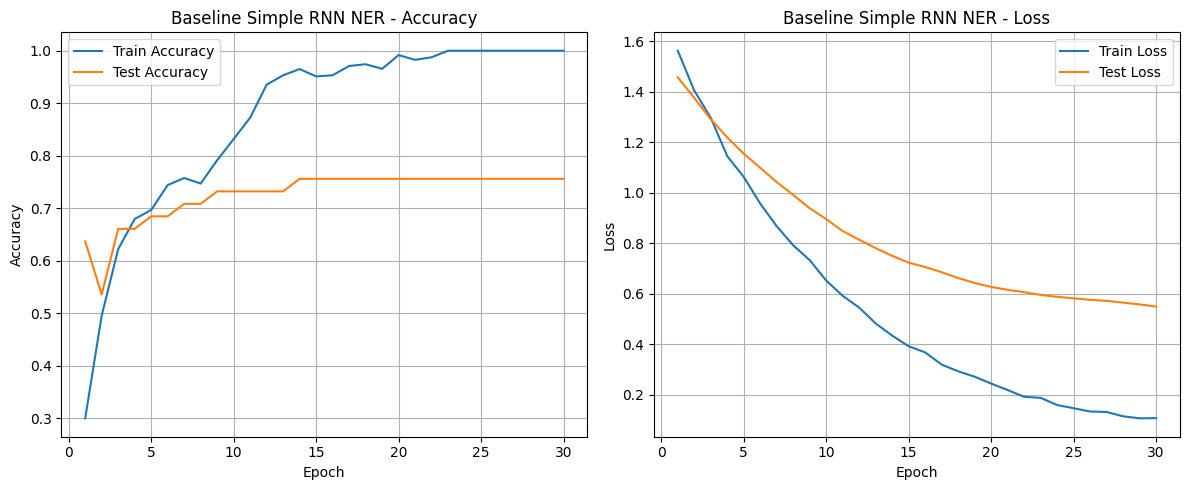

In [10]:
plot_history(
    baseline_history,
    "Baseline Simple RNN NER",
    "images/tutorial_14A_baseline_training_curves.png"
)


## 11. Predict NER Labels for a New Sentence

In [11]:
def tokenize_sentence(sentence):
    # Simple tokenizer: keep words and remove punctuation
    tokens = re.findall(r"[A-Za-z]+", sentence)
    return tokens


def predict_ner(model, sentence):
    model.eval()

    tokens = tokenize_sentence(sentence)
    encoded = [word_to_idx.get(word.lower(), word_to_idx[UNK_TOKEN]) for word in tokens]

    # Pad or truncate to max_len
    encoded_padded = encoded[:max_len] + [word_to_idx[PAD_TOKEN]] * max(0, max_len - len(encoded))
    encoded_padded = encoded_padded[:max_len]

    input_tensor = torch.tensor([encoded_padded], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        predictions = torch.argmax(logits, dim=-1).cpu().numpy()[0]

    results = []

    for token, pred_idx in zip(tokens[:max_len], predictions[:len(tokens)]):
        results.append((token, idx_to_label[pred_idx]))

    return results


test_sentence = "Elon Musk visited Google in London"

baseline_predictions = predict_ner(baseline_model, test_sentence)

print("Sentence:", test_sentence)
print("\nPredicted NER labels:")

for word, label in baseline_predictions:
    print(f"{word:12s} -> {label}")


Sentence: Elon Musk visited Google in London

Predicted NER labels:
Elon         -> PERSON
Musk         -> PERSON
visited      -> O
Google       -> O
in           -> O
London       -> LOCATION


## 12. Save Prediction Results as Image

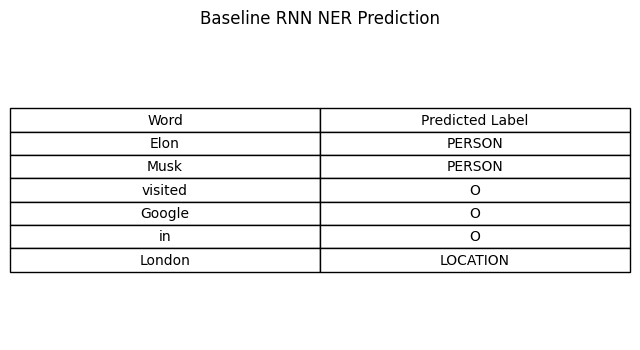

,Word,Predicted Label
0,Elon,PERSON
1,Musk,PERSON
2,visited,O
3,Google,O
4,in,O
5,London,LOCATION


In [12]:
def save_predictions_table(predictions, filename, title):
    df = pd.DataFrame(predictions, columns=["Word", "Predicted Label"])

    fig, ax = plt.subplots(figsize=(8, max(2.5, len(df) * 0.45 + 1.2)))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)

    ax.set_title(title, fontsize=12, pad=12)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    return df


baseline_prediction_df = save_predictions_table(
    baseline_predictions,
    "images/tutorial_14A_baseline_prediction_table.png",
    "Baseline RNN NER Prediction"
)

baseline_prediction_df


# Task — Change Units, Epochs, and Learning Rate

The tutorial task asks to change:

- Number of hidden units
- Number of epochs
- Learning rate

Several configurations are tested and compared.


In [13]:
experiment_configs = [
    {
        "Name": "Small_RNN",
        "Hidden Units": 32,
        "Epochs": 20,
        "Learning Rate": 0.001
    },
    {
        "Name": "Baseline_RNN",
        "Hidden Units": 64,
        "Epochs": 30,
        "Learning Rate": 0.001
    },
    {
        "Name": "Large_RNN",
        "Hidden Units": 128,
        "Epochs": 30,
        "Learning Rate": 0.001
    },
    {
        "Name": "High_LR",
        "Hidden Units": 64,
        "Epochs": 30,
        "Learning Rate": 0.01
    },
    {
        "Name": "Low_LR",
        "Hidden Units": 64,
        "Epochs": 30,
        "Learning Rate": 0.0005
    }
]

experiment_results = []
experiment_histories = {}
experiment_models = {}

for config in experiment_configs:
    print("\nTraining:", config["Name"])

    torch.manual_seed(SEED)

    model = SimpleRNNNER(
        vocab_size=len(word_to_idx),
        embedding_dim=64,
        hidden_dim=config["Hidden Units"],
        num_labels=len(label_to_idx),
        dropout_rate=0.2
    ).to(device)

    history, training_time = train_rnn_ner(
        model,
        train_loader,
        test_loader,
        epochs=config["Epochs"],
        learning_rate=config["Learning Rate"]
    )

    experiment_results.append({
        "Model": config["Name"],
        "Hidden Units": config["Hidden Units"],
        "Epochs": config["Epochs"],
        "Learning Rate": config["Learning Rate"],
        "Final Train Acc": history["train_accuracy"][-1],
        "Final Test Acc": history["test_accuracy"][-1],
        "Final Train Loss": history["train_loss"][-1],
        "Final Test Loss": history["test_loss"][-1],
        "Training Time (s)": training_time,
        "Trainable Parameters": count_trainable_parameters(model)
    })

    experiment_histories[config["Name"]] = history
    experiment_models[config["Name"]] = model

experiment_results_df = pd.DataFrame(experiment_results)
experiment_results_df



Training: Small_RNN
Epoch 1/20 | Train Loss: 1.6869 | Test Loss: 1.6335 | Train Acc: 18.38% | Test Acc: 14.29%
Epoch 5/20 | Train Loss: 1.3973 | Test Loss: 1.4843 | Train Acc: 53.88% | Test Acc: 26.19%
Epoch 10/20 | Train Loss: 1.0226 | Test Loss: 1.3101 | Train Acc: 77.27% | Test Acc: 41.07%
Epoch 15/20 | Train Loss: 0.7876 | Test Loss: 1.1673 | Train Acc: 76.37% | Test Acc: 55.95%
Epoch 20/20 | Train Loss: 0.5952 | Test Loss: 1.0229 | Train Acc: 88.90% | Test Acc: 55.95%

Training: Baseline_RNN
Epoch 1/30 | Train Loss: 1.5624 | Test Loss: 1.4570 | Train Acc: 29.98% | Test Acc: 63.69%
Epoch 5/30 | Train Loss: 1.0628 | Test Loss: 1.1546 | Train Acc: 69.65% | Test Acc: 68.45%
Epoch 10/30 | Train Loss: 0.6526 | Test Loss: 0.8958 | Train Acc: 83.17% | Test Acc: 73.21%
Epoch 15/30 | Train Loss: 0.3925 | Test Loss: 0.7235 | Train Acc: 95.10% | Test Acc: 75.60%
Epoch 20/30 | Train Loss: 0.2448 | Test Loss: 0.6274 | Train Acc: 99.17% | Test Acc: 75.60%
Epoch 25/30 | Train Loss: 0.1472 | Test

,Model,Hidden Units,Epochs,Learning Rate,Final Train Acc,Final Test Acc,Final Train Loss,Final Test Loss,Training Time (s),Trainable Parameters
0,Small_RNN,32,20,0.0010,0.889021,0.559524,0.595179,1.022900,0.337006,9573
1,Baseline_RNN,64,30,0.0010,1.000000,0.755952,0.107961,0.549639,0.558278,14917
2,Large_RNN,128,30,0.0010,1.000000,0.779762,0.031648,0.694951,0.522229,31749
3,High_LR,64,30,0.0100,1.000000,0.755952,0.000916,0.720882,0.544649,14917
4,Low_LR,64,30,0.0005,0.949476,0.755952,0.384105,0.719385,0.486993,14917


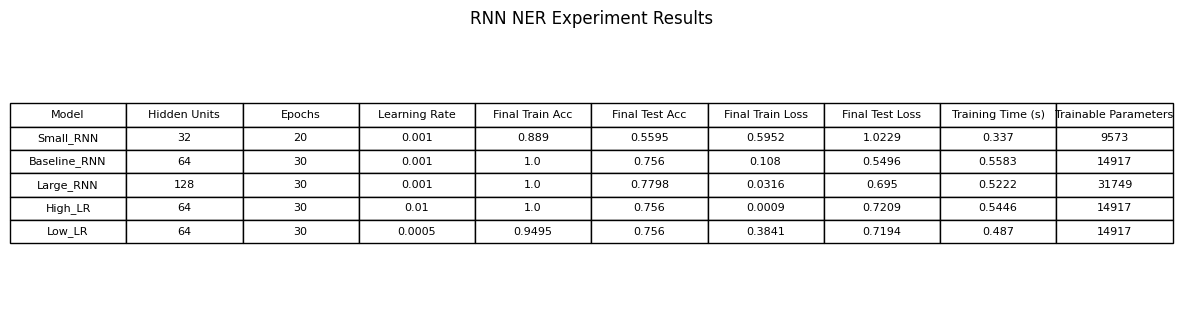

In [14]:
def save_dataframe_as_image(df, filename, title=None):
    fig_width = max(8, len(df.columns) * 1.5)
    fig_height = max(2.5, len(df) * 0.45 + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.4)

    if title:
        ax.set_title(title, fontsize=12, pad=12)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


experiment_image_df = experiment_results_df.copy()

for column in ["Final Train Acc", "Final Test Acc", "Final Train Loss", "Final Test Loss", "Training Time (s)"]:
    experiment_image_df[column] = experiment_image_df[column].round(4)

save_dataframe_as_image(
    experiment_image_df,
    "images/tutorial_14A_experiment_results_table.png",
    title="RNN NER Experiment Results"
)


## 13. Compare Experiment Curves

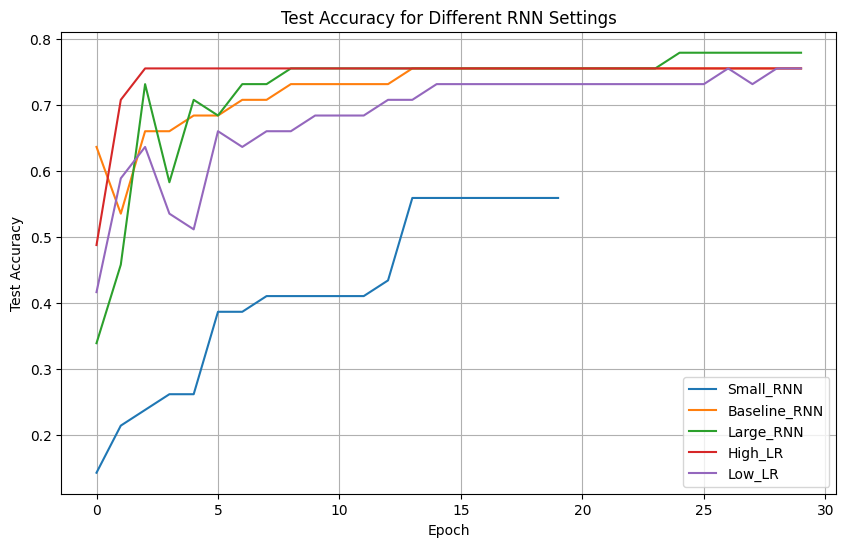

In [15]:
plt.figure(figsize=(10, 6))

for model_name, history in experiment_histories.items():
    plt.plot(history["test_accuracy"], label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy for Different RNN Settings")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_14A_experiment_accuracy_curves.png", dpi=300, bbox_inches="tight")
plt.show()


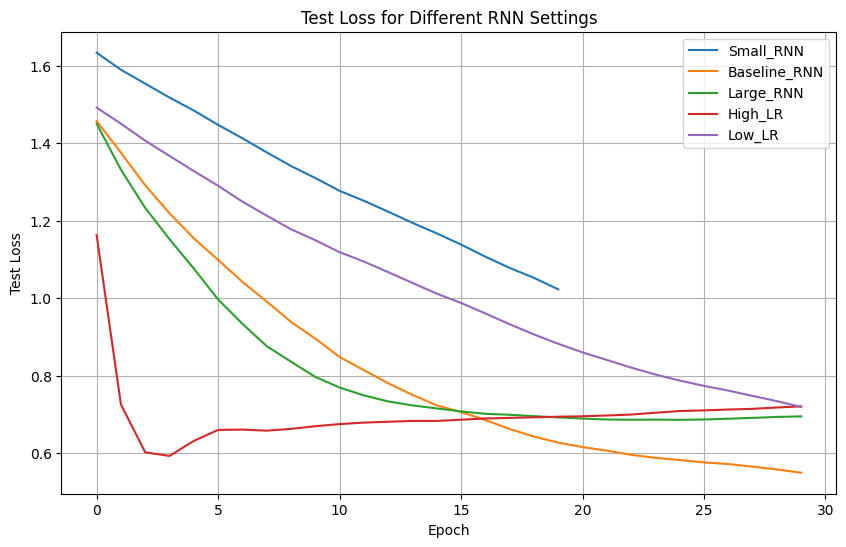

In [16]:
plt.figure(figsize=(10, 6))

for model_name, history in experiment_histories.items():
    plt.plot(history["test_loss"], label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss for Different RNN Settings")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_14A_experiment_loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()


## 14. Best Model Prediction

Best model: Large_RNN
Model                   Large_RNN
Hidden Units                  128
Epochs                         30
Learning Rate               0.001
Final Train Acc               1.0
Final Test Acc           0.779762
Final Train Loss         0.031648
Final Test Loss          0.694951
Training Time (s)        0.522229
Trainable Parameters        31749
Name: 2, dtype: object

Sentence: Ayesha joined OpenAI in San Francisco

Predicted NER labels:
Ayesha       -> PERSON
joined       -> O
OpenAI       -> O
in           -> O
San          -> LOCATION
Francisco    -> LOCATION


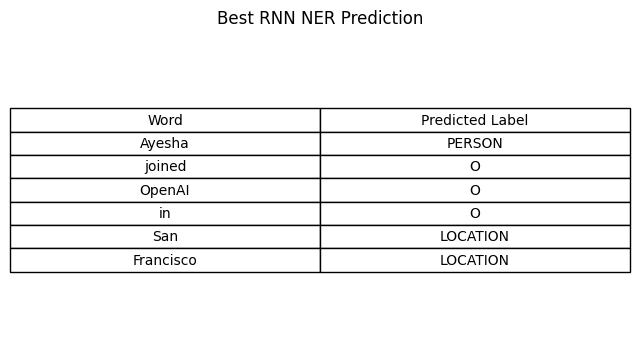

,Word,Predicted Label
0,Ayesha,PERSON
1,joined,O
2,OpenAI,O
3,in,O
4,San,LOCATION
5,Francisco,LOCATION


In [17]:
best_row = experiment_results_df.sort_values(by="Final Test Acc", ascending=False).iloc[0]

best_model_name = best_row["Model"]
best_model = experiment_models[best_model_name]

print("Best model:", best_model_name)
print(best_row)

test_sentence_2 = "Ayesha joined OpenAI in San Francisco"

best_predictions = predict_ner(best_model, test_sentence_2)

print("\nSentence:", test_sentence_2)
print("\nPredicted NER labels:")

for word, label in best_predictions:
    print(f"{word:12s} -> {label}")

best_prediction_df = save_predictions_table(
    best_predictions,
    "images/tutorial_14A_best_model_prediction_table.png",
    "Best RNN NER Prediction"
)

best_prediction_df


# Final Observations

## Baseline RNN

The baseline Simple RNN processes the sentence word by word and predicts a label for each token.

## Own Dataset

A small custom NER dataset was created with PERSON, LOCATION, ORGANIZATION, and O labels.

## Experiment Results

Different hidden unit sizes, epochs, and learning rates were tested.

Changing the hidden units changes the capacity of the model.  
Changing the learning rate affects how quickly the model learns.  
Changing the number of epochs affects how long the model trains.

## Key Learning

RNNs are useful for sequence data because they process tokens in order.  
For NER, the model needs to predict a label at each time step, so the output is also a sequence.
